1. Data Exploration:

a. Load the dataset and perform exploratory data analysis (EDA).

In [1]:
# Loading the diabetes dataset 
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


b. Examine the features, their types, and summary statistics.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.shape

(768, 9)

c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

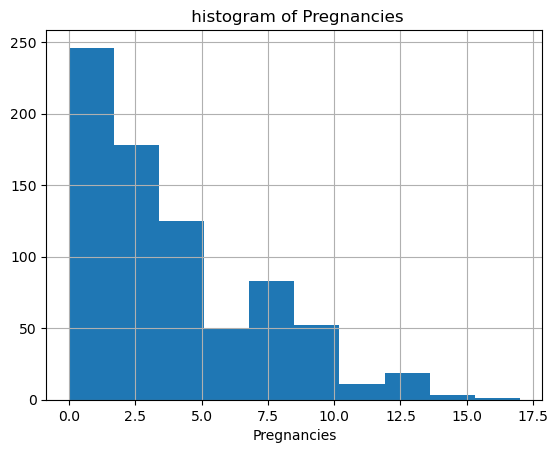

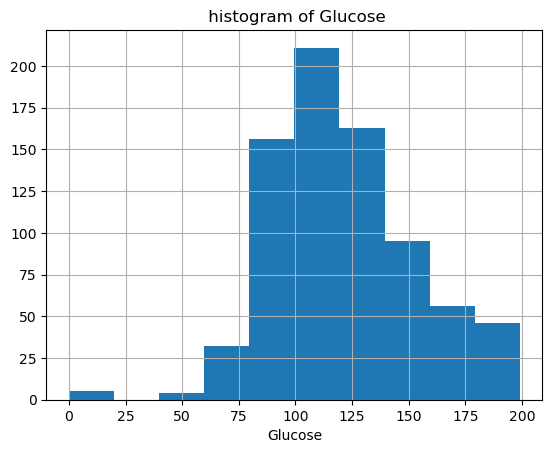

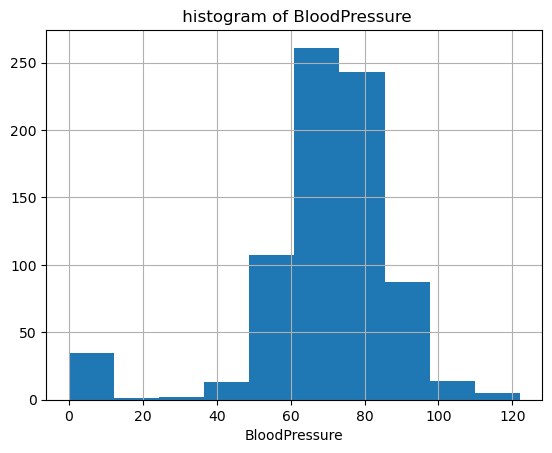

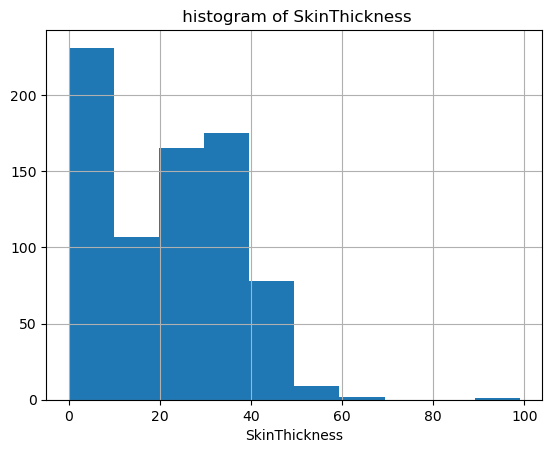

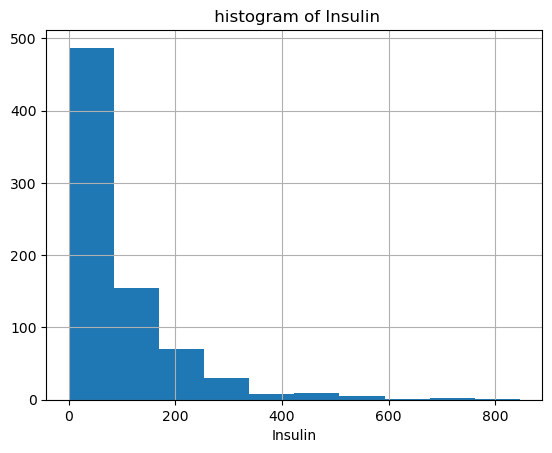

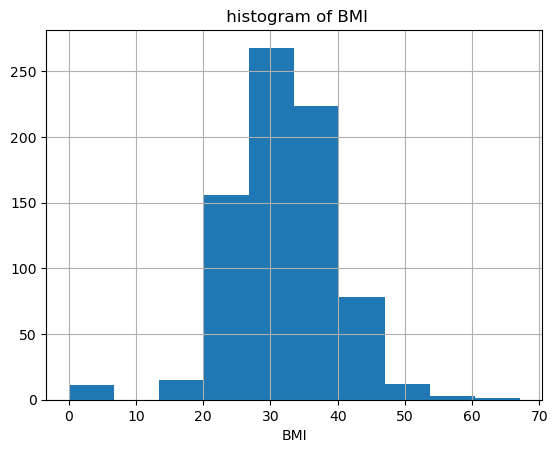

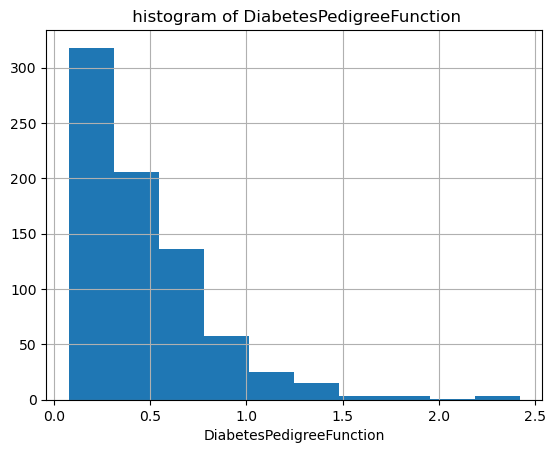

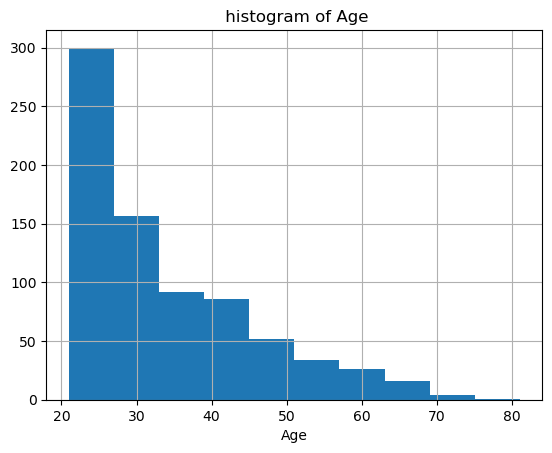

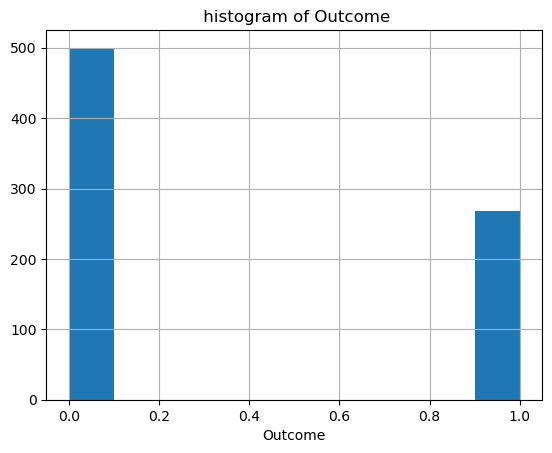

In [5]:
# Performing histogram for dataset
import matplotlib.pyplot as plt
for i in df.select_dtypes(include="number").columns:
    df[i].hist()
    plt.xlabel(i)
    plt.title(f" histogram of {i}")
    plt.show()

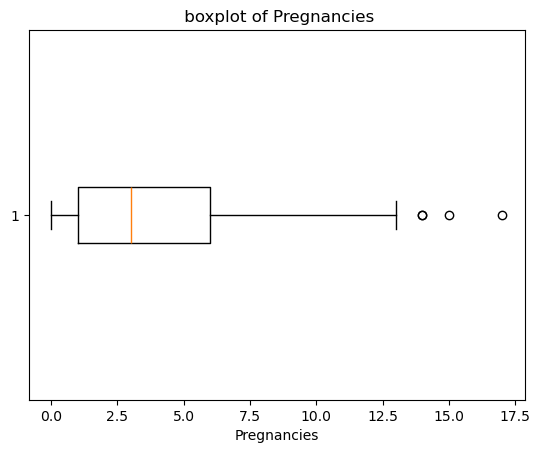

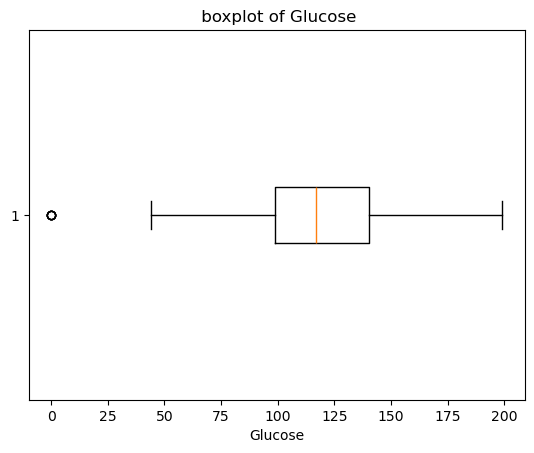

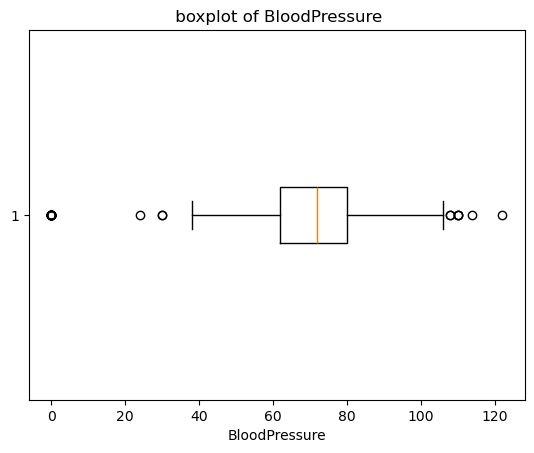

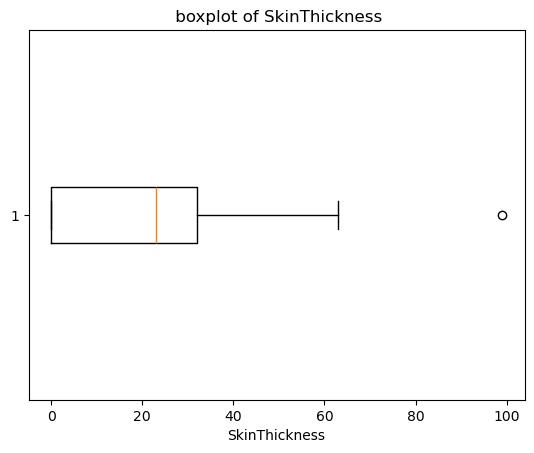

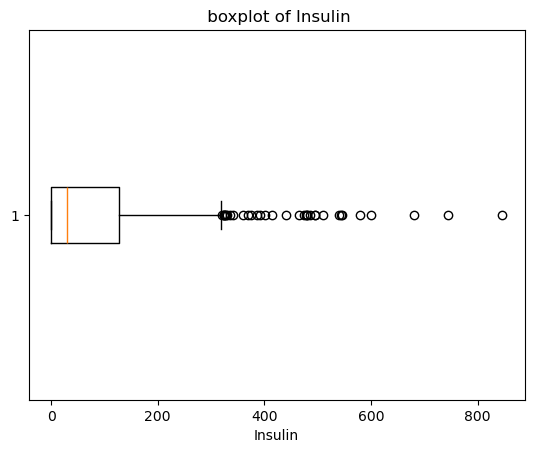

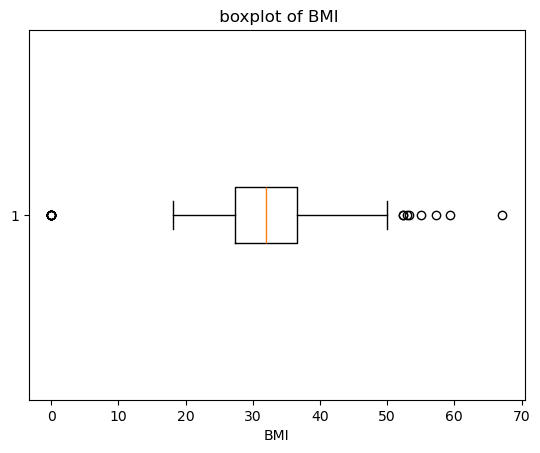

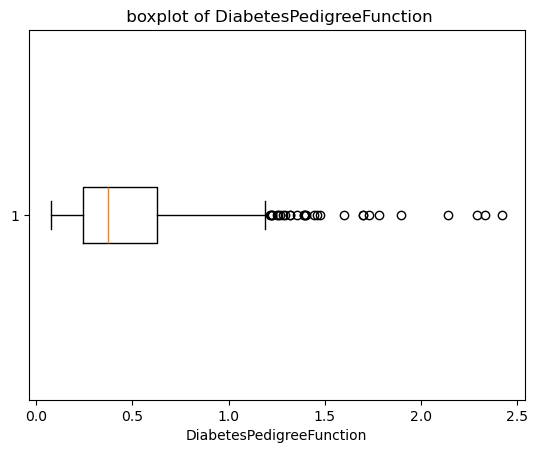

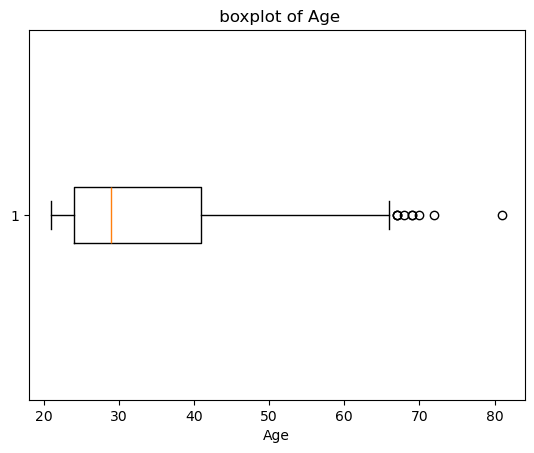

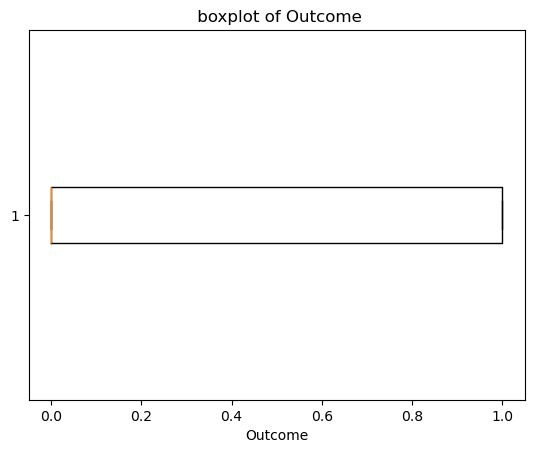

In [6]:
# Performing boxplot for variables
for y in df.select_dtypes(include="number").columns:
    plt.boxplot(x=df[y],vert=False)
    plt.xlabel(y)
    plt.title(f" boxplot of {y}")
    plt.show()
# Checking outliers by using boxplot 

In [7]:
# Finding nearest wiskers length for the outliers
import numpy as np
for y in df.select_dtypes(include="number").columns:
    Q1 =np.percentile(df[y],25)
    Q3 =np.percentile(df[y],75)
    print("Q1:",Q1)
    print("Q3:",Q3)
    IQR = Q3-Q1
    UW= Q3+(1.5*IQR)
    LW= Q1-(1.5*IQR)
    print("Upper whisker:",UW)
    print("Lower whisker:",LW)
    # outliers idenfication 
    print("Total number of outliers:",len(df[df[y]>UW]))
    print("Total number of outliers:",len(df[df[y]<LW]))

    df.loc[df[y]>UW,y]=UW
    df.loc[df[y]<LW,y]=LW

Q1: 1.0
Q3: 6.0
Upper whisker: 13.5
Lower whisker: -6.5
Total number of outliers: 4
Total number of outliers: 0
Q1: 99.0
Q3: 140.25
Upper whisker: 202.125
Lower whisker: 37.125
Total number of outliers: 0
Total number of outliers: 5
Q1: 62.0
Q3: 80.0
Upper whisker: 107.0
Lower whisker: 35.0
Total number of outliers: 7
Total number of outliers: 38
Q1: 0.0
Q3: 32.0
Upper whisker: 80.0
Lower whisker: -48.0
Total number of outliers: 1
Total number of outliers: 0
Q1: 0.0
Q3: 127.25
Upper whisker: 318.125
Lower whisker: -190.875
Total number of outliers: 34
Total number of outliers: 0
Q1: 27.3
Q3: 36.6
Upper whisker: 50.550000000000004
Lower whisker: 13.35
Total number of outliers: 8
Total number of outliers: 11
Q1: 0.24375
Q3: 0.62625
Upper whisker: 1.2
Lower whisker: -0.32999999999999996
Total number of outliers: 29
Total number of outliers: 0
Q1: 24.0
Q3: 41.0
Upper whisker: 66.5
Lower whisker: -1.5
Total number of outliers: 9
Total number of outliers: 0
Q1: 0.0
Q3: 1.0
Upper whisker: 2.5

C:\Users\nannu\AppData\Local\Temp\ipykernel_33364\746209366.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[y]>UW,y]=UW
C:\Users\nannu\AppData\Local\Temp\ipykernel_33364\746209366.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '202.125' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[y]>UW,y]=UW
C:\Users\nannu\AppData\Local\Temp\ipykernel_33364\746209366.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '318.125' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[y]>UW,y]=UW
C:\Users\nannu\AppData\Local\Temp\ipykernel_33364\74620

In [8]:
# After applying nearest wisker lengths
# Checking outliers 
import numpy as np
for y in df.select_dtypes(include="number").columns:
    Q1 =np.percentile(df[y],25)
    Q3 =np.percentile(df[y],75)
    print("Q1:",Q1)
    print("Q3:",Q3)
    IQR = Q3-Q1
    UW= Q3+(1.5*IQR)
    LW= Q1-(1.5*IQR)
    print("Upper whisker:",UW)
    print("Lower whisker:",LW)
    # outliers idenfication 
    print("Total number of outliers:",len(df[df[y]>UW]))
    print("Total number of outliers:",len(df[df[y]<LW]))
    

Q1: 1.0
Q3: 6.0
Upper whisker: 13.5
Lower whisker: -6.5
Total number of outliers: 0
Total number of outliers: 0
Q1: 99.0
Q3: 140.25
Upper whisker: 202.125
Lower whisker: 37.125
Total number of outliers: 0
Total number of outliers: 0
Q1: 62.0
Q3: 80.0
Upper whisker: 107.0
Lower whisker: 35.0
Total number of outliers: 0
Total number of outliers: 0
Q1: 0.0
Q3: 32.0
Upper whisker: 80.0
Lower whisker: -48.0
Total number of outliers: 0
Total number of outliers: 0
Q1: 0.0
Q3: 127.25
Upper whisker: 318.125
Lower whisker: -190.875
Total number of outliers: 0
Total number of outliers: 0
Q1: 27.3
Q3: 36.6
Upper whisker: 50.550000000000004
Lower whisker: 13.35
Total number of outliers: 0
Total number of outliers: 0
Q1: 0.24375
Q3: 0.62625
Upper whisker: 1.2
Lower whisker: -0.32999999999999996
Total number of outliers: 0
Total number of outliers: 0
Q1: 24.0
Q3: 41.0
Upper whisker: 66.5
Lower whisker: -1.5
Total number of outliers: 0
Total number of outliers: 0
Q1: 0.0
Q3: 1.0
Upper whisker: 2.5
Low

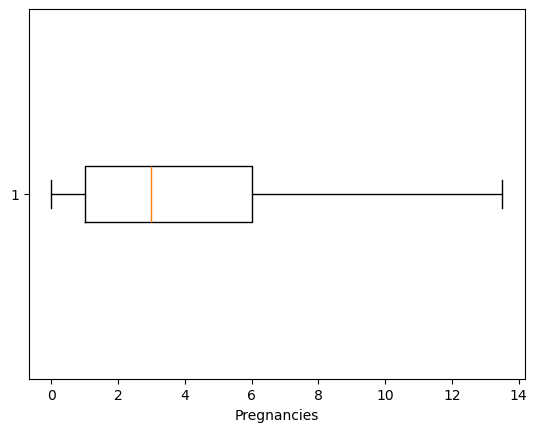

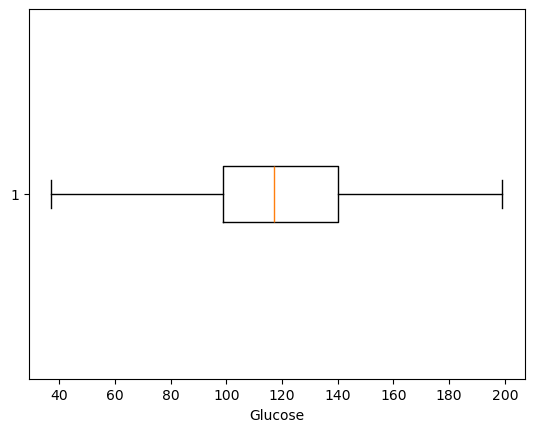

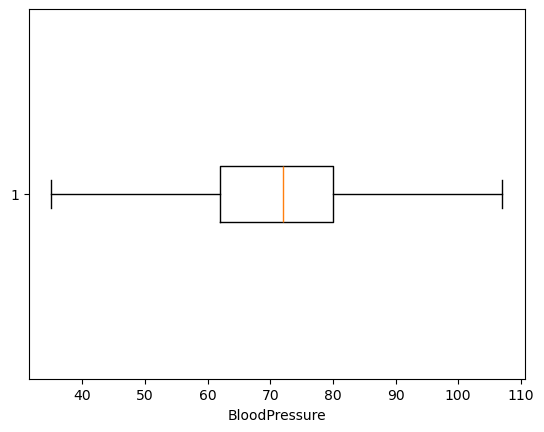

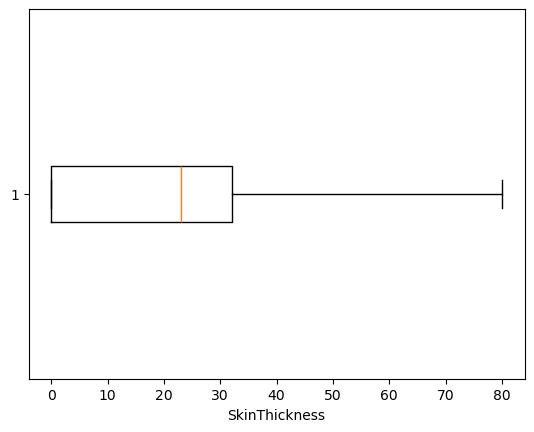

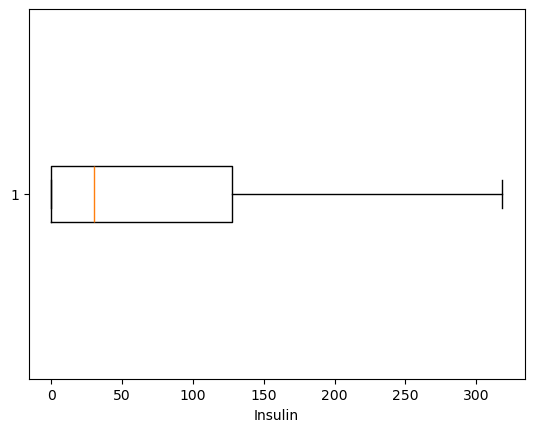

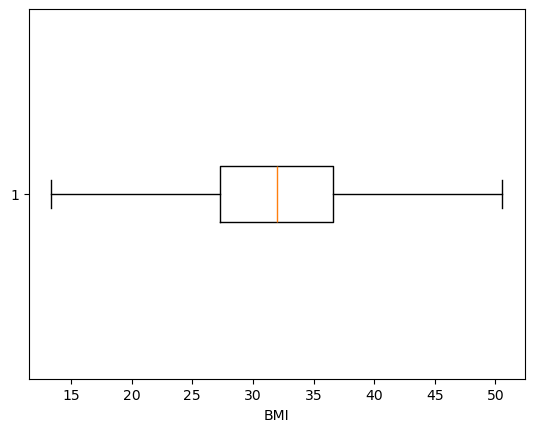

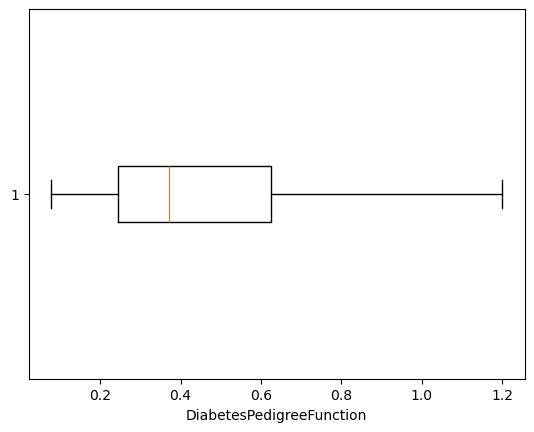

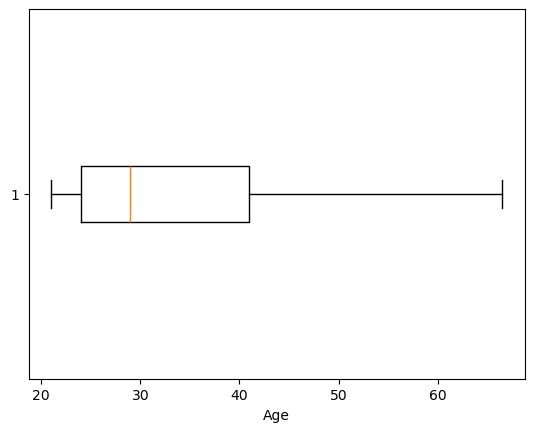

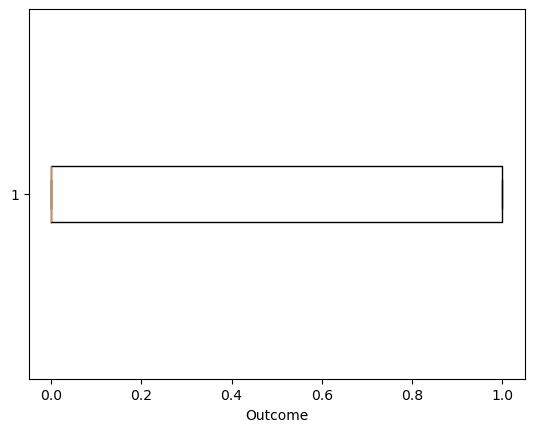

In [12]:
# After applying nearest wisker lengths
# Checking outliers 
for y1 in df.select_dtypes(include="number").columns:
    plt.boxplot(x=df[y1],vert=False)
    plt.xlabel(y1)
    plt.show()

Analyze any patterns or correlations observed in the data.

In [13]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128987,0.184307,-0.084349,-0.077793,0.024681,-0.017398,0.549695,0.220392
Glucose,0.128987,1.000000,0.197865,0.059806,0.315856,0.235542,0.120213,0.269056,0.479158
BloodPressure,0.184307,0.197865,1.000000,0.152644,0.050080,0.282544,0.038793,0.304208,0.113301
SkinThickness,-0.084349,0.059806,0.152644,1.000000,0.488101,0.401494,0.177920,-0.119170,0.073125
Insulin,-0.077793,0.315856,0.050080,0.488101,1.000000,0.209665,0.190087,-0.065547,0.124721
BMI,0.024681,0.235542,0.282544,0.401494,0.209665,1.000000,0.141087,0.043375,0.309739
DiabetesPedigreeFunction,-0.017398,0.120213,0.038793,0.177920,0.190087,0.141087,1.000000,0.047289,0.184969
Age,0.549695,0.269056,0.304208,-0.119170,-0.065547,0.043375,0.047289,1.000000,0.242702
Outcome,0.220392,0.479158,0.113301,0.073125,0.124721,0.309739,0.184969,0.242702,1.000000


2. Data Preprocessing:

a. Handle missing values (e.g., imputation).

In [14]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

b. Encode categorical variables.

In [16]:
# Dropping the target variable from the dataset
# Seperating continuous variables into x variables
# Seperating target variables into y variable 
# For y no need transformation because its already present in label encoding 
x=df.drop("Outcome",axis=1)
y=df["Outcome"]

In [17]:
# Standardization for continuous variables
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X=SS.fit_transform(x)
SS_X=pd.DataFrame(SS_X)
SS_X.columns =list(x)
SS_X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.647150,0.861926,0.092691,0.914986,-0.787602,0.209359,0.588927,1.445691
1,-0.848970,-1.159433,-0.330201,0.536065,-0.787602,-0.784254,-0.378101,-0.189304
2,1.245598,1.984903,-0.471166,-1.295388,-0.787602,-1.252672,0.746595,-0.103252
3,-0.848970,-1.031093,-0.330201,0.157144,0.217583,-0.571337,-1.022787,-1.049828
4,-1.148194,0.508990,-2.162737,0.914986,1.008900,1.557835,2.596563,-0.017199
...,...,...,...,...,...,...,...,...
763,1.844045,-0.646072,0.374620,1.735982,1.137221,0.109998,-1.008772,2.564372
764,-0.549746,0.027714,-0.048273,0.409758,-0.787602,0.663583,-0.416642,-0.533513
765,0.347926,-0.004371,0.092691,0.157144,0.410066,-0.841032,-0.749497,-0.275356
766,-0.848970,0.156054,-0.753094,-1.295388,-0.787602,-0.287447,-0.385109,1.187534


3. Model Building:

a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).

In [18]:
# Importing appropriate libraries 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Splitting the data into training an testing
x_train,x_test,y_train,y_test=train_test_split(SS_X,y,test_size=0.2,random_state=42)

# Creating a model
model=LogisticRegression()

b. Train the model using the training data.

In [19]:
# Training the model 
model.fit(x_train,y_train)
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

# Calculating the accuracy score of training and test data
train_score = accuracy_score(y_train,y_pred_train)
print(f"train score is :",np.round(train_score,2))
test_score = accuracy_score(y_test,y_pred_test)
print(f"test score is :",np.round(test_score,2))

train score is : 0.78
test score is : 0.75


In [20]:
# Applying the cross validation 
from sklearn.model_selection import ShuffleSplit,cross_validate
ss=ShuffleSplit(n_splits=500,test_size=0.2,random_state=42)
cv=cross_validate(model,SS_X,y,cv=ss,scoring="accuracy",return_train_score=True)

train_scores=cv["train_score"]
test_scores=cv["test_score"]

print(f"cross_validation : train_score: {np.round(train_scores.mean(),2)}")
print(f"cross_validation : test_score: {np.round(test_scores.mean(),2)}")


cross_validation : train_score: 0.78
cross_validation : test_score: 0.77


4. Model Evaluation:

a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.

In [21]:
# Checking the test score, precision, f1 score and recall
import numpy as np
from sklearn.metrics import recall_score,precision_score,f1_score

test_score=accuracy_score(y_test,y_pred_test)
print(f"test score is: {np.round(test_score,2)}")

r_score=recall_score(y_test,y_pred_test)
print(f"the sensitivity is: {np.round(r_score,2)}")

s_score=recall_score(y_pred_test,y_test)
print(f"the specificity is: {np.round(s_score,2)}")

p_score=precision_score(y_test,y_pred_test)
print(f"the precision_score is: {np.round(p_score,2)}")

f1score=f1_score(y_test,y_pred_test)
print(f"the f1_score is: {np.round(f1score,2)}")

test score is: 0.75
the sensitivity is: 0.65
the specificity is: 0.65
the precision_score is: 0.65
the f1_score is: 0.65


Visualize the ROC curve.

In [22]:
# Finding the probability values for x test 
model = LogisticRegression()
model.fit(x_train, y_train)  # we must fit the model before finding the probabilty value. without fitting we get an error    

y_pred_prob=model.predict_proba(x_test)[:,1]
y_pred_prob

array([0.26987511, 0.17548174, 0.10923614, 0.17641831, 0.44908957,
       0.42501867, 0.01405473, 0.64514794, 0.52814663, 0.7821414 ,
       0.23073454, 0.89054357, 0.29313391, 0.34705849, 0.09204809,
       0.43330808, 0.13501227, 0.06892319, 0.82031474, 0.58146094,
       0.19527015, 0.0714012 , 0.51582361, 0.08924385, 0.51591331,
       0.8877853 , 0.11385884, 0.02461241, 0.2275162 , 0.11562808,
       0.90776687, 0.88820755, 0.74051677, 0.82405125, 0.67247171,
       0.70322908, 0.97124615, 0.26973332, 0.48976576, 0.68319662,
       0.06579433, 0.65019151, 0.61107053, 0.32921551, 0.0216143 ,
       0.51425236, 0.66778889, 0.22587438, 0.39551263, 0.96838979,
       0.04237428, 0.66316976, 0.79975941, 0.26006478, 0.07840053,
       0.03746381, 0.78311363, 0.01238189, 0.455536  , 0.76106227,
       0.74723963, 0.3596607 , 0.16578311, 0.21289296, 0.06760082,
       0.63561591, 0.04850568, 0.73368193, 0.03614336, 0.81300036,
       0.68720093, 0.06304182, 0.16807989, 0.10580524, 0.08422

In [23]:
# Finding the roc curve values
from sklearn.metrics import roc_curve,roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) #threshold values are dummy values

auc=roc_auc_score(y_test,y_pred_prob)
print(f"area under curve is: {np.round(auc,2)}")


area under curve is: 0.81


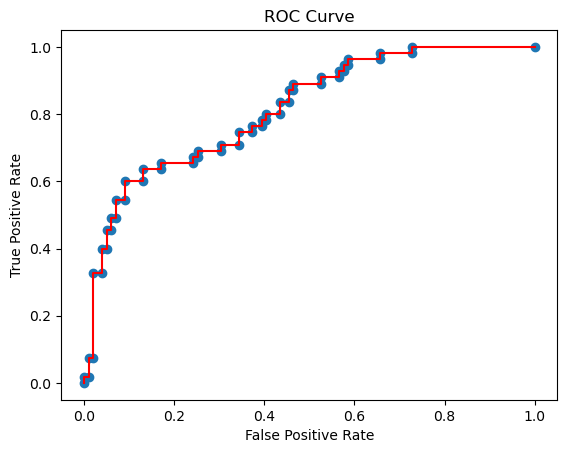

In [24]:
# Visualizing the roc curve
import matplotlib.pyplot as plt
plt.scatter(fpr, tpr)
plt.plot(fpr, tpr,color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


5. Interpretation:

a. Interpret the coefficients of the logistic regression model.

In [25]:
# coefficient interpretation
coeff= pd.DataFrame({
    "Features":x.columns,
    "Coefficients": model.coef_[0]
})
coeff

,Features,Coefficients
0,Pregnancies,0.200366
1,Glucose,1.088289
2,BloodPressure,-0.249305
3,SkinThickness,0.036520
4,Insulin,-0.218544
5,BMI,0.777954
6,DiabetesPedigreeFunction,0.284662
7,Age,0.449256


b. Discuss the significance of features in predicting the target variable (survival probability in this case).

The significance of features in predicting the target variable are

1) DaibetesPedigreeFunction : Moderatley important(coeff=0.284)

==> In a family if a person has a strong diabetes then there may be chance of causing diabets.

2) BMI : Important(coeff= 0.777)
   
==> Having obisity may have high chanecs of diabetes
   
3) Age: Moderatley imp (coeff = 0.449)

==> As age increases there may be chances of having diabetes

4) Glucose: Highly important(coeff=1.088)

==> Higher glucose level greatly increases diabetes level.

5) I think by obeserving the coeff of reamaning featuers may show less imapct for the diabetes because they are near to 0 and less than zero.


6. Deployment with Streamlit:

In [26]:
import pickle

# save model
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(model, f)

# if you used StandardScaler()
with open("SS.pkl", "wb") as f:
    pickle.dump(SS, f)


Interview Questions:

1. What is the difference between precision and recall?

==> Recall which calculates the overall actual positives how much our model successfully predicted them as positive.

==> If false negative increases recall decreases and if it false negative decreases, then recall will increases.

==> Precision which calculates out of predicted postives it detects how much are correct.

==> If false positive changes then specificity, accuracy and precision will change.

2. What is cross-validation, and why is it important in binary classification?

Cross Validation :

===> Cross validation is a resampling technique used to evaluate machine learning models by splitting tha dataset into multiple folds and training/testing the model multiple times.

because a simple train_test split has problems:

==> Model performance depends heavily on how we split

==> Possible high varience

==> Not a reliable estimate of true model accuracy.

Cross-validation solves all these problems by:

==> Repeating training/testeing proecess many times.

==> Averaging the results

Why it is important in binary classification :

==> Prevents overfitting.

==> Gives more reliable performance estimate.

==> Uses data efficiently.

==> Helps hyperparameter tuninng.

==> Handling imbalance classes better.

